## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [1]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func

#data_dir = '/project/InTEM_GHG/inversion/PARIS_results_sharing/'
data_dir = '/home/h02/aramsden/results/multi_gas_MCMC/processed_output/'

model_filenames = {'intem_edgar':'InTEM_NAME_EUROPE_EDGAR_intem_obs*',
                   'intem_edgar_sapr':'InTEM_NAME_EUROPE_EDGAR_ScaledByPrior_intem_obs*',
                   'intem_edgar_allobs':'InTEM_NAME_EUROPE_EDGAR_all_obs*',
                   'intem_flat':'InTEM_NAME_EUROPE_FLATBYREGION_intem_obs*',
                   'intem_flat_sapr':'InTEM_NAME_EUROPE_FLATBYREGION_ScaledByPrior_intem_obs*',
                   'intem_oldflat':'InTEM_NAME_EUROPE_FLAT_intem_obs*',
                   'intem_oldflat_allobs':'InTEM_NAME_EUROPE_FLAT_all_obs*',
                  'elris_edgar':'ELRIS_NAME_EUROPE_EDGAR*',
                  'elris_flat':'ELRIS_NAME_EUROPE_FLAT*',
                  'rhime_edgar':'RHIME_NAME_EUROPE_EDGAR_rhime_obs*',
                  'rhime_edgar_allobs':'RHIME_NAME_EUROPE_EDGAR_all_obs*',
                  'mcmc_oldflux':'MCMC_NAME_EUROPE_250basis*',
                  'mcmc_2gas':'MCMC_NAME_EUROPE_2sector-2gas*',
                  'mcmc':'MCMC_NAME_EUROPE_mean_250basis_std-uncert*',
                  'mcmc_prop-uncert':'MCMC_NAME_EUROPE_mean_250basis_prop-uncert*',
                  'intem':'InTEM_NAME_EUROPE_Jan*'}

model_labels = {'intem_edgar':'InTEM EDGAR',
                   'intem_edgar_sapr':'InTEM EDGAR ScaledByPrior',
                   'intem_edgar_allobs':'InTEM EDGAR all obs',
                   'intem_flat':'InTEM FLAT',
                   'intem_flat_sapr':'InTEM FLAT ScaledByPrior',
                   'intem_oldflat':'InTEM old FLAT',
                   'intem_oldflat_allobs':'InTEM old FLAT all obs',
                  'elris_edgar':'ELRIS EDGAR',
                  'elris_flat':'ELRIS FLAT',
                  'rhime_edgar':'RHIME EDGAR',
                  'rhime_edgar_allobs':'RHIME EDGAR all obs',
                  'mcmc_oldflux':'MCMC old flux',
                  'mcmc_2gas':'MCMC 2 gas',
                  'mcmc':'MCMC',
                  'mcmc_prop-uncert':'MCMC proportional and min model error',
                  'intem':'InTEM'}

model_colors = {'intem_edgar':['darkblue','dodgerblue'],
                   'intem_edgar_sapr':['darkblue','dodgerblue'],
                   'intem_edgar_allobs':['darkgreen','green'],
                   'intem_flat':['firebrick','darkorange'],
                   'intem_flat_sapr':['purple','mediumpurple'],
                   'intem_oldflat':['purple','mediumpurple'],
                   'intem_oldflat_allobs':['darkblue','dodgerblue'],
                'elris_edgar':['purple','mediumpurple'],
                'elris_flat':['darkblue','dodgerblue'],#['teal','darkturquoise'],
                'rhime_edgar':['teal','darkturquoise'],
                'rhime_edgar_allobs':['orange','gold'],
                'mcmc_oldflux':['teal','darkturquoise'],
                'mcmc_2gas':['orange','gold'],
                'mcmc':['teal','darkturquoise'],
                'mcmc_prop-uncert':['purple','mediumpurple'],
                'intem':['darkblue','dodgerblue']}

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [ ]:
###################################
### edit variables in this block
species = 'ch4' #'hfc125'
plot_regions = ['UK','FRANCE','GERMANY','IRELAND'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
#models = ['intem_edgar','intem_flat','intem_oldflat']
#models = ['intem_edgar','intem_edgar_allobs']
#models = ['intem_edgar','elris_edgar','rhime_edgar']
#models = ['intem_edgar','intem_edgar_allobs','rhime_edgar','rhime_edgar_allobs']
#models = ['intem_flat','elris_flat']
#models = ['intem_flat','elris_flat','intem_edgar','elris_edgar',]
#models = ['intem_edgar','elris_edgar','rhime_edgar']
models = ['mcmc','mcmc_2gas','mcmc_prop-uncert','intem']
start_date = '2018-01-01' #inclusive
end_date = '2020-01-01' #not inclusive
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]

#ds_all_flux_scaled = func.slice_flux(ds_all_flux,start_date,end_date,scale_units=True,
#                                species=species)

#### Timeseries of country fluxes:

In [ ]:
###################################
### edit variables in this block
plot_inventory = False
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,plot_regions,model_labels,
                             model_colors,
                             plot_inventory,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg)

Save plot here:

In [ ]:
output_path = '/home/h02/aramsden/results/PARIS_results_comparison/hfc125_may2024/country_flux_h125_all_models_diff_prior.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
ds_all_mf['mcmc_prop-uncert'].sel({'time_ch4':slice(start_date,end_date)})

In [ ]:
import numpy as np
a = np.unique(ds_all_mf['mcmc']['time_ch4'].values)
print(a.shape)
print(ds_all_mf['mcmc']['time_ch4'].values.shape)

In [ ]:
ds_all_mf['mcmc']['time_ch4'].values[-1000:]

In [2]:
###################################
### edit variables in this block
species = 'ch4' 
site = 'TAC'
#models = ['intem_edgar','intem_flat','intem_oldflat']
#models = ['intem_edgar','intem_edgar_allobs']
#models = ['intem_flat','elris_flat']
#models = ['intem_edgar','elris_edgar','rhime_edgar']
models = ['mcmc','mcmc_prop-uncert']
start_date = '2019-01-01' #inclusive
end_date = '2020-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs          - total observed mole fraction
# uYobs         - total observed mole fraction uncertainty
# uYmod         - total model mole fraction uncertainty
# Yapriori      - prior total mole fraction
# Yapost        - posterior total mole fraction
# YaprioriBC    - prior baseline
# YapostBC      - posterior baseline
# Ybias         - posterior bias added to site
# YaprioriOuter - prior mole fractions only from outer regions
# YapostOuter   - posterior mole fractions only from outer regions
###################################


ds_all_mf = func.read_mf(data_dir,species,models,model_filenames)

ds_all_mf_sliced = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)


Attempting to read data from mcmc
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_mean_250basis_std-uncert_ch4_monthly_concentrations.nc
Done!

Attempting to read data from mcmc_prop-uncert
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/MCMC/ch4/MCMC_NAME_EUROPE_mean_250basis_prop-uncert_ch4_monthly_concentrations.nc
Done!

Masking data from mcmc
Scaling mcmc units by 1e-09

Masking data from mcmc_prop-uncert
Scaling mcmc_prop-uncert units by 1e-09


/home/h02/aramsden/.conda/envs/all/lib/python3.10/site-packages/xarray/core/indexes.py:501: FutureWarning: Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is deprecated and will raise a KeyError in a future Version.
  indexer = index.slice_indexer(
/home/h02/aramsden/.conda/envs/all/lib/python3.10/site-packages/xarray/core/indexes.py:501: FutureWarning: Value based partial slicing on non-monotonic DatetimeIndexes with non-existing keys is deprecated and will raise a KeyError in a future Version.
  indexer = index.slice_indexer(


#### Timeseries plot, separated by model:

KeyError: 'Yobs'

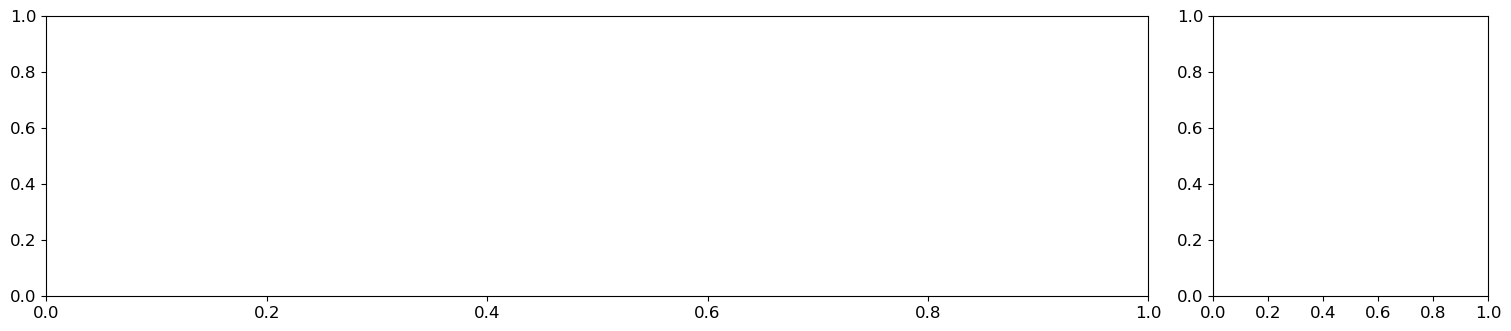

In [4]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs','YapostBC'],
                             diff_include=['YapostBC'])

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
###################################

In [ ]:
output_path = '/home/h02/aramsden/results/PARIS_results_comparison/hfc125_may2024/Yobs_YapostBC_JFJ_h125_all_models_flat_2020.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs'],
                             diff_include=['Yapost'])

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs'],
                             diff_include=['Yapost'])

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites)

fig = func.plot_stats_mf(pearson,nrmse,species,model_labels,
                         model_colors,
                  start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [ ]:
###################################
### edit variables in this block
species = 'hfc125'
start_date = '2018-01-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2023-01-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
#models = ['intem_edgar','intem_flat','intem_oldflat']
#models = ['intem_edgar','intem_edgar_sapr','intem_flat','intem_flat_sapr']
#models = ['intem_edgar','intem_edgar_allobs']
#models = ['intem_edgar','elris_edgar','rhime_edgar']
#models = ['intem_edgar_sapr','intem_edgar_allobs_sapr','rhime_edgar','rhime_edgar_allobs']
models = ['intem_flat_sapr','elris_flat','intem_edgar_sapr','elris_edgar']
#models = ['intem_edgar_sapr','elris_edgar','rhime_edgar']
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames)

ds_all_flux_scaled = func.slice_flux(ds_all_flux.copy(),start_date,end_date,scale_units=True,
                                species=species)

##### Prior and posterior fluxes for all models:

In [ ]:
###################################
### edit variables in this block
plot_area = 'CWEU' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,model_labels,cmap='viridis',border_color_in='floralwhite',
                             cmap_diff='coolwarm')

In [ ]:
output_path = '/home/h02/aramsden/results/PARIS_results_comparison/hfc125_may2024/spatial_flux_cweu_h125_all_models_all_prior.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

##### Directly compare posterior fluxes from two models:

In [ ]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,model_labels)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')